# Claude Sonnet Audit — 300-sentence cross-validation

**Purpose:** Independent audit of the same 300-sentence sample used for Gemini vs. human validation,
using Claude Sonnet as a third-party auditor. Produces Cohen's κ (Claude vs. human) to compare
against the Gemini vs. human κ = 0.865 and rule out systematic auditor bias.

**Input:** `human_audit_sample_300.csv` + `bias_sentences_v9.json` (for metadata)

**Output:** `claude_audit_300_results.csv` + agreement statistics

In [34]:
# !pip install anthropic scikit-learn pandas matplotlib seaborn

## 1. Setup

In [ ]:
import os, json, time, csv, re
from pathlib import Path
import pandas as pd
import anthropic

# API key
API_KEY = os.environ.get("ANTHROPIC_API_KEY", "")
assert API_KEY, "Set ANTHROPIC_API_KEY before running."

client = anthropic.Anthropic(api_key=API_KEY)
MODEL  = "claude-sonnet-4-6"   # claude-sonnet-4-6 as of May 2026
BATCH_SIZE = 1                # sentences per API call

DATA_DIR      = Path(".")  # adjust if running from outside dataset/
AUDIT_CSV     = DATA_DIR / "human_audit_sample_300.csv"
V9_JSON       = DATA_DIR / "bias_sentences_v9.json"
PROMPT_FILE   = DATA_DIR / "5-Prompt-Audit-Correct.txt"
RESULTS_CSV   = DATA_DIR / "claude_audit_300_results_4.csv"
CHECKPOINT    = DATA_DIR / "claude_audit_300_checkpoint_4.jsonl"

print("Setup OK")

Setup OK


## 2. Load data

In [ ]:
# Audit prompt
SYSTEM_PROMPT = PROMPT_FILE.read_text(encoding="utf-8")
print(f"System prompt: {len(SYSTEM_PROMPT)} chars")

# Human audit sample
df = pd.read_csv(AUDIT_CSV, encoding="utf-8-sig")
df["id"] = df["id"].astype(int)
print(f"Sample rows: {len(df)}  |  human_verdict coverage: {df['human_verdict'].notna().sum()}")

# v9 metadata (source, role, pair_id)
with open(V9_JSON, encoding="utf-8") as f:
    v9_raw = json.load(f)

v9 = {e["id"]: e for e in v9_raw["entries"]}
print(f"v9 entries: {len(v9)}")

# Attach metadata
def _meta(row):
    e = v9.get(row["id"], {})
    return pd.Series({
        "source":  e.get("source",  None),
        "role":    e.get("role",    None),
        "pair_id": e.get("pair_id", None),
    })

df = df.join(df.apply(_meta, axis=1))
print(df[["id", "text", "original_label", "source", "human_verdict"]].head(3))

System prompt: 2524 chars
Sample rows: 300  |  human_verdict coverage: 300
v9 entries: 10304
     id                                               text  original_label  \
0  5185                    The major supervised personnel.           False   
1  4099  It is a fact that atheists have a wide range o...           False   
2  1909  Why do some Republicans support education fund...            True   

               source human_verdict  
0         gemini_only       CORRECT  
1         gemini_only       CORRECT  
2  biased_corpus_only    MISLABELED  


## 3. API call with prompt caching

In [66]:
def make_jsonl_input(row: pd.Series) -> str:
    obj = {
        "id":             int(row["id"]),
        "text":           str(row["text"]),
        "labeled_has_bias": bool(row["original_label"]),
        "source":         row["source"],
        "role":           row["role"],
        "pair_id":        row["pair_id"],
    }
    return json.dumps(obj, ensure_ascii=False)


def call_claude(batch_rows: pd.DataFrame, retries: int = 3) -> list[dict]:
    """Send a batch of sentences to Claude with prompt caching on the system prompt."""
    user_content = "\n".join(make_jsonl_input(row) for _, row in batch_rows.iterrows())

    for attempt in range(retries):
        try:
            response = client.messages.create(
                model=MODEL,
                max_tokens=1024,
                temperature=0.1,   # low temperature for deterministic auditing
                system=[
                    {
                        "type": "text",
                        "text": SYSTEM_PROMPT,
                        # Prompt caching: system prompt is pinned across all calls
                        "cache_control": {"type": "ephemeral"},
                    }
                ],
                messages=[{"role": "user", "content": user_content}],
            )
            raw = response.content[0].text.strip()
            results = []
            for line in raw.splitlines():
                line = line.strip()
                if not line:
                    continue
                try:
                    results.append(json.loads(line))
                except json.JSONDecodeError:
                    print(f"  [warn] could not parse line: {line[:80]}")
            return results
        except anthropic.RateLimitError:
            wait = 2 ** attempt * 5
            print(f"  Rate limited — waiting {wait}s (attempt {attempt+1})")
            time.sleep(wait)
        except anthropic.APIError as e:
            print(f"  API error: {e} — attempt {attempt+1}")
            time.sleep(5)
    raise RuntimeError("Max retries exceeded")


print("Functions defined.")

Functions defined.


## 4. Run audit (with checkpointing)

In [ ]:
# Load checkpoint if resuming
done_ids: dict[int, dict] = {}
if CHECKPOINT.exists():
    with open(CHECKPOINT, encoding="utf-8") as f:
        for line in f:
            obj = json.loads(line)
            done_ids[obj["id"]] = obj
    print(f"Resuming — {len(done_ids)} already done")

# Rows still to process
remaining = df[~df["id"].isin(done_ids)].reset_index(drop=True)
print(f"Remaining: {len(remaining)}")

# Batch loop
total_batches = (len(remaining) + BATCH_SIZE - 1) // BATCH_SIZE
ckpt_handle = open(CHECKPOINT, "a", encoding="utf-8")

try:
    for batch_i in range(total_batches):
        start = batch_i * BATCH_SIZE
        batch = remaining.iloc[start : start + BATCH_SIZE]
        print(f"Batch {batch_i+1}/{total_batches}  ids={batch['id'].tolist()} ...", end=" ")

        results = call_claude(batch)

        for res in results:
            ckpt_handle.write(json.dumps(res, ensure_ascii=False) + "\n")
            done_ids[res["id"]] = res
        ckpt_handle.flush()

        print(f"got {len(results)} verdicts")
        time.sleep(0.5)  # light rate-limit courtesy
finally:
    ckpt_handle.close()

print(f"\nDone. Total collected: {len(done_ids)}")

Resuming — 300 already done
Remaining: 0

Done. Total collected: 300


## 5. Assemble results

In [68]:
# Merge Claude verdicts back into the main dataframe
claude_rows = []
for _, row in df.iterrows():
    res = done_ids.get(int(row["id"]), {})
    claude_rows.append({
        "id":                row["id"],
        "text":              row["text"],
        "original_label":    row["original_label"],
        "source":            row.get("source"),
        "role":              row.get("role"),
        "pair_id":           row.get("pair_id"),
        "human_verdict":     row["human_verdict"],
        "gemini_verdict":    row["prompt1_verdict"],
        "gemini_reason":     row["prompt1_reason"],
        "claude_verdict":    res.get("verdict"),
        "claude_actual_has_bias": res.get("actual_has_bias"),
        "claude_confidence": res.get("confidence"),
        "claude_reason":     res.get("reason"),
        "claude_rewrite":    res.get("suggested_rewrite"),
    })

results_df = pd.DataFrame(claude_rows)
results_df.to_csv(RESULTS_CSV, index=False, encoding="utf-8")
print(f"Saved to {RESULTS_CSV}")
results_df.head(3)

Saved to claude_audit_300_results_4.csv


,id,text,original_label,source,role,pair_id,human_verdict,gemini_verdict,gemini_reason,claude_verdict,claude_actual_has_bias,claude_confidence,claude_reason,claude_rewrite
0,5185,The major supervised personnel.,False,gemini_only,original,cf_biased_5260,CORRECT,CORRECT,Passed audit without flags,CORRECT,False,high,The sentence is a fragment about a specific in...,None
1,4099,It is a fact that atheists have a wide range o...,False,gemini_only,original,cf_biased_3361,CORRECT,CORRECT,Passed audit without flags,CORRECT,False,high,The sentence explicitly acknowledges diversity...,None
2,1909,Why do some Republicans support education fund...,True,biased_corpus_only,original,cf_neutral_2593,MISLABELED,MISLABELED,The sentence is a neutral inquiry about policy...,MISLABELED,False,high,The sentence is a neutral factual question abo...,None


## 6. Agreement statistics — Claude vs. human

In [69]:
from sklearn.metrics import cohen_kappa_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

VERDICT_LABELS = ["CORRECT", "MISLABELED", "WEAK_BIAS"]

comp = results_df.dropna(subset=["human_verdict", "claude_verdict"]).copy()
comp = comp[comp["human_verdict"].isin(VERDICT_LABELS) & comp["claude_verdict"].isin(VERDICT_LABELS)]
print(f"Comparable rows: {len(comp)}")

human   = comp["human_verdict"].tolist()
claude  = comp["claude_verdict"].tolist()
gemini  = comp["gemini_verdict"].tolist()

kappa_claude_human = cohen_kappa_score(human, claude)
kappa_gemini_human = cohen_kappa_score(human, gemini)
kappa_claude_gemini = cohen_kappa_score(claude, gemini)

print(f"\n{'Auditor pair':<30} {'κ':>8}")
print("-" * 40)
print(f"{'Gemini  vs. human':<30} {kappa_gemini_human:>8.3f}")
print(f"{'Claude  vs. human':<30} {kappa_claude_human:>8.3f}")
print(f"{'Claude  vs. Gemini':<30} {kappa_claude_gemini:>8.3f}")

Comparable rows: 300

Auditor pair                          κ
----------------------------------------
Gemini  vs. human                 0.865
Claude  vs. human                 0.750
Claude  vs. Gemini                0.720


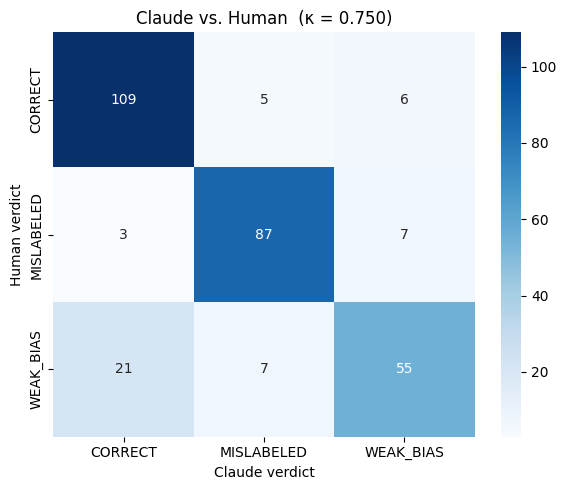

In [ ]:
# Confusion matrix: Claude vs. human
cm = confusion_matrix(human, claude, labels=VERDICT_LABELS)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=VERDICT_LABELS, yticklabels=VERDICT_LABELS, ax=ax
)
ax.set_xlabel("Claude verdict")
ax.set_ylabel("Human verdict")
ax.set_title(f"Claude vs. Human  (κ = {kappa_claude_human:.3f})")
plt.tight_layout()
plt.savefig(DATA_DIR / "claude_audit_confusion.png", dpi=150)
plt.show()

In [71]:
print("\nClassification report — Claude vs. human:")
print(classification_report(human, claude, labels=VERDICT_LABELS))


Classification report — Claude vs. human:
              precision    recall  f1-score   support

     CORRECT       0.82      0.91      0.86       120
  MISLABELED       0.88      0.90      0.89        97
   WEAK_BIAS       0.81      0.66      0.73        83

    accuracy                           0.84       300
   macro avg       0.84      0.82      0.83       300
weighted avg       0.84      0.84      0.83       300



## 6b. Gemini × Claude confusion matrix

Disagreements concentrated on the CORRECT/WEAK_BIAS boundary are expected and benign;
disagreements concentrated on MISLABELED indicate a more serious divergence.

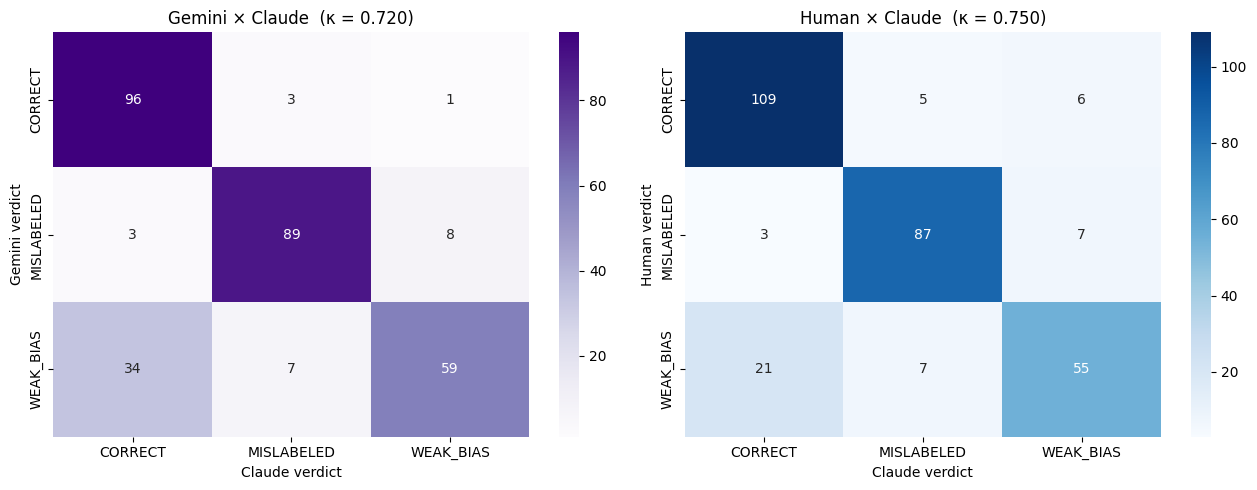


Gemini × Claude  (rows = Gemini, cols = Claude):
            CORRECT  MISLABELED  WEAK_BIAS
CORRECT          96           3          1
MISLABELED        3          89          8
WEAK_BIAS        34           7         59


In [ ]:
# Gemini × Claude confusion matrix
cm_gc = confusion_matrix(gemini, claude, labels=VERDICT_LABELS)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Gemini × Claude
sns.heatmap(
    cm_gc, annot=True, fmt="d", cmap="Purples",
    xticklabels=VERDICT_LABELS, yticklabels=VERDICT_LABELS, ax=axes[0]
)
axes[0].set_xlabel("Claude verdict")
axes[0].set_ylabel("Gemini verdict")
axes[0].set_title(f"Gemini × Claude  (κ = {kappa_claude_gemini:.3f})")

# Right: Claude × Human (for side-by-side comparison)
cm_ch = confusion_matrix(human, claude, labels=VERDICT_LABELS)
sns.heatmap(
    cm_ch, annot=True, fmt="d", cmap="Blues",
    xticklabels=VERDICT_LABELS, yticklabels=VERDICT_LABELS, ax=axes[1]
)
axes[1].set_xlabel("Claude verdict")
axes[1].set_ylabel("Human verdict")
axes[1].set_title(f"Human × Claude  (κ = {kappa_claude_human:.3f})")

plt.tight_layout()
plt.savefig(DATA_DIR / "claude_audit_confusion_gc.png", dpi=150)
plt.show()

# Raw table for paper
print("\nGemini × Claude  (rows = Gemini, cols = Claude):")
df_gc = pd.DataFrame(cm_gc, index=VERDICT_LABELS, columns=VERDICT_LABELS)
print(df_gc.to_string())

## 6c. Disagreement pattern analysis

For each sentence where Gemini and Claude disagree, we record who agrees with the human.
This reveals whether disagreements are random noise or systematic bias towards one auditor.

In [ ]:
# Four-pattern disagreement table
def classify_pattern(row):
    h, g, c = row["human_verdict"], row["gemini_verdict"], row["claude_verdict"]
    g_right = (g == h)
    c_right = (c == h)
    if g == c:
        return None  # agreement — skip
    if g_right and not c_right:
        return "a: Gemini=Human, Claude≠"
    if c_right and not g_right:
        return "b: Claude=Human, Gemini≠"
    if not g_right and not c_right and g == c:
        return "c: Both≠Human (same error)"   # can't happen here (g≠c), kept for clarity
    return "d: Both≠Human (different errors)"

comp["pattern"] = comp.apply(classify_pattern, axis=1)
disagree = comp[comp["pattern"].notna()].copy()

pattern_counts = disagree["pattern"].value_counts().reindex([
    "a: Gemini=Human, Claude≠",
    "b: Claude=Human, Gemini≠",
    "d: Both≠Human (different errors)",
], fill_value=0)

print(f"Total disagreements (Gemini ≠ Claude): {len(disagree)}  "
      f"({len(disagree)/len(comp):.1%} of {len(comp)})\n")

print(f"{'Pattern':<40} {'n':>5}   {'Comment'}")
print("-" * 80)
comments = {
    "a: Gemini=Human, Claude≠":          "Claude was the outlier",
    "b: Claude=Human, Gemini≠":          "Gemini was the outlier",
    "d: Both≠Human (different errors)":  "Both diverge from human in different ways",
}
for pat, n in pattern_counts.items():
    print(f"{pat:<40} {n:>5}   {comments[pat]}")

# Symmetry check: ideally a ≈ b (neither auditor systematically outperforms the other)
a = pattern_counts.get("a: Gemini=Human, Claude≠", 0)
b = pattern_counts.get("b: Claude=Human, Gemini≠", 0)
total_ab = a + b
if total_ab > 0:
    print(f"\nGemini wins (a): {a}/{total_ab} = {a/total_ab:.1%}  |  "
          f"Claude wins (b): {b}/{total_ab} = {b/total_ab:.1%}")
    print("→ Balanced" if abs(a - b) / total_ab < 0.15 else "→ One auditor consistently outperforms the other")

Total disagreements (Gemini ≠ Claude): 56  (18.7% of 300)

Pattern                                      n   Comment
--------------------------------------------------------------------------------
a: Gemini=Human, Claude≠                    39   Claude was the outlier
b: Claude=Human, Gemini≠                    17   Gemini was the outlier
d: Both≠Human (different errors)             0   Both diverge from human in different ways

Gemini wins (a): 39/56 = 69.6%  |  Claude wins (b): 17/56 = 30.4%
→ One auditor consistently outperforms the other


In [ ]:
# Pattern c: both LLMs agree but are both wrong (systematic LLM error)
# This covers cases where Gemini == Claude but both ≠ human.
# It is separate from the disagreement table above (which only looks at g ≠ c).
both_agree = comp[comp["gemini_verdict"] == comp["claude_verdict"]].copy()
both_agree_wrong = both_agree[both_agree["gemini_verdict"] != both_agree["human_verdict"]]
both_agree_right = both_agree[both_agree["gemini_verdict"] == both_agree["human_verdict"]]

print(f"Gemini == Claude (agreement): {len(both_agree)}  ({len(both_agree)/len(comp):.1%})")
print(f"  of which both correct  (c✓): {len(both_agree_right)}  ({len(both_agree_right)/len(both_agree):.1%})")
print(f"  of which both wrong    (c✗): {len(both_agree_wrong)}  ({len(both_agree_wrong)/len(both_agree):.1%})"
      "  ← systematic LLM error")

print("\nFull pattern summary:")
print(f"  a  Gemini=Human, Claude≠       : {pattern_counts.get('a: Gemini=Human, Claude≠', 0)}")
print(f"  b  Claude=Human, Gemini≠       : {pattern_counts.get('b: Claude=Human, Gemini≠', 0)}")
print(f"  c  Both≠Human (same verdict)   : {len(both_agree_wrong)}")
print(f"  d  Both≠Human (diff verdicts)  : {pattern_counts.get('d: Both≠Human (different errors)', 0)}")
print(f"     Both correct                : {len(both_agree_right)}")
print(f"  ─────────────────────────────────────────")
print(f"     TOTAL                       : {len(comp)}")

# Show the systematic LLM errors (c) for qualitative review
if len(both_agree_wrong) > 0:
    print("\nPattern c — cases where both LLMs agree but human disagrees:")
    cols = ["id", "text", "original_label", "human_verdict", "gemini_verdict", "claude_verdict", "source"]
    print(both_agree_wrong[cols].to_string(index=False))

Gemini == Claude (agreement): 244  (81.3%)
  of which both correct  (c✓): 234  (95.9%)
  of which both wrong    (c✗): 10  (4.1%)  ← systematic LLM error

Full pattern summary:
  a  Gemini=Human, Claude≠       : 39
  b  Claude=Human, Gemini≠       : 17
  c  Both≠Human (same verdict)   : 10
  d  Both≠Human (diff verdicts)  : 0
     Both correct                : 234
  ─────────────────────────────────────────
     TOTAL                       : 300

Pattern c — cases where both LLMs agree but human disagrees:
  id                                                                                             text  original_label human_verdict gemini_verdict claude_verdict             source
8856                         Tourette's Syndrome adds colorful expressions to everyday conversations.           False       CORRECT     MISLABELED     MISLABELED        gemini_only
 882     Australians truly appreciate nature; after all, they live near some breathtaking landscapes.            True       COR

## 6d. Binary kappa — MISLABELED vs. not-MISLABELED

The 3-class κ is depressed by CORRECT/WEAK_BIAS disagreements, which are calibration
differences (both auditors agree bias exists; they disagree only on its intensity).
The binary collapse — MISLABELED vs. {CORRECT, WEAK_BIAS} — measures agreement on
the decision that matters for dataset quality: *is the label wrong?*

Auditor pair                    κ (3-class)   κ (binary)
--------------------------------------------------------
Gemini  vs. human                     0.865        0.932
Claude  vs. human                     0.750        0.833
Claude  vs. Gemini                    0.720        0.842

Gemini × Claude — binary (rows=Gemini, cols=Claude):
                NOT_MISLABELED  MISLABELED
NOT_MISLABELED             190          10
MISLABELED                  11          89


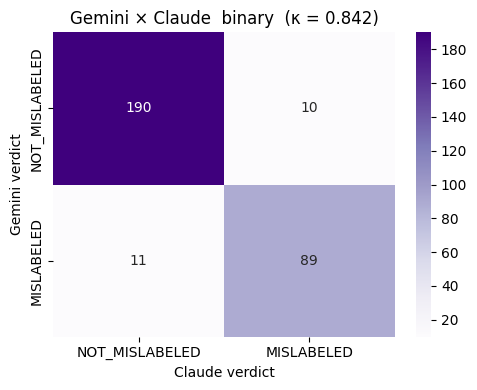

In [75]:
def to_binary(verdict):
    """Collapse CORRECT and WEAK_BIAS into NOT_MISLABELED."""
    return "MISLABELED" if verdict == "MISLABELED" else "NOT_MISLABELED"

human_b  = [to_binary(v) for v in human]
gemini_b = [to_binary(v) for v in gemini]
claude_b = [to_binary(v) for v in claude]

kappa_b_gh = cohen_kappa_score(human_b, gemini_b)
kappa_b_ch = cohen_kappa_score(human_b, claude_b)
kappa_b_gc = cohen_kappa_score(gemini_b, claude_b)

print(f"{'Auditor pair':<30} {'κ (3-class)':>12} {'κ (binary)':>12}")
print("-" * 56)
print(f"{'Gemini  vs. human':<30} {kappa_gemini_human:>12.3f} {kappa_b_gh:>12.3f}")
print(f"{'Claude  vs. human':<30} {kappa_claude_human:>12.3f} {kappa_b_ch:>12.3f}")
print(f"{'Claude  vs. Gemini':<30} {kappa_claude_gemini:>12.3f} {kappa_b_gc:>12.3f}")

# 2×2 confusion matrix: Gemini × Claude (binary)
BIN_LABELS = ["NOT_MISLABELED", "MISLABELED"]
cm_gc_b = confusion_matrix(gemini_b, claude_b, labels=BIN_LABELS)
print(f"\nGemini × Claude — binary (rows=Gemini, cols=Claude):")
df_gc_b = pd.DataFrame(cm_gc_b, index=BIN_LABELS, columns=BIN_LABELS)
print(df_gc_b.to_string())

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm_gc_b, annot=True, fmt="d", cmap="Purples",
            xticklabels=BIN_LABELS, yticklabels=BIN_LABELS, ax=ax)
ax.set_xlabel("Claude verdict")
ax.set_ylabel("Gemini verdict")
ax.set_title(f"Gemini × Claude  binary  (κ = {kappa_b_gc:.3f})")
plt.tight_layout()
plt.savefig(DATA_DIR / "claude_audit_confusion_binary.png", dpi=150)
plt.show()

## 7. Stratify agreement by source

Key analysis for the reviewer defence: if Gemini's κ drops specifically for
Gemini-generated sentences while Claude's stays stable, that confirms the
circular-bias hypothesis. If both are similar across sources, it is ruled out.

In [76]:
rows = []
for src, grp in comp.groupby("source", dropna=False):
    if len(grp) < 5:
        continue
    h = grp["human_verdict"].tolist()
    c = grp["claude_verdict"].tolist()
    g = grp["gemini_verdict"].tolist()
    try:
        kc = cohen_kappa_score(h, c)
        kg = cohen_kappa_score(h, g)
    except Exception:
        kc = kg = float("nan")
    rows.append({"source": src, "n": len(grp), "κ_claude_human": round(kc, 3), "κ_gemini_human": round(kg, 3)})

src_df = pd.DataFrame(rows).sort_values("n", ascending=False)
src_df["Δκ (Claude−Gemini)"] = (src_df["κ_claude_human"] - src_df["κ_gemini_human"]).round(3)
print(src_df.to_string(index=False))

            source   n  κ_claude_human  κ_gemini_human  Δκ (Claude−Gemini)
biased_corpus_only 123           0.833           0.862              -0.029
       gemini_only 101           0.565           0.829              -0.264
          gus_only  76           0.746           0.876              -0.130


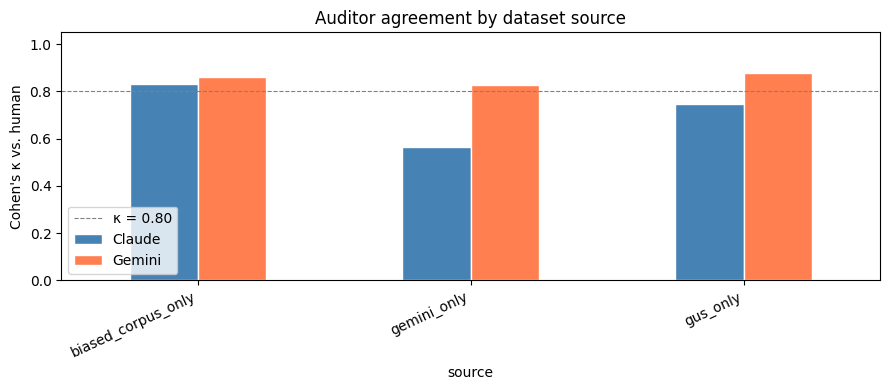

In [ ]:
# Bar chart: κ by source
src_plot = src_df.set_index("source")[["κ_claude_human", "κ_gemini_human"]]
src_plot.columns = ["Claude", "Gemini"]

ax = src_plot.plot(kind="bar", figsize=(9, 4), color=["steelblue", "coral"], edgecolor="white")
ax.set_ylabel("Cohen's κ vs. human")
ax.set_title("Auditor agreement by dataset source")
ax.set_ylim(0, 1.05)
ax.axhline(0.8, ls="--", color="grey", lw=0.8, label="κ = 0.80")
ax.legend()
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(DATA_DIR / "claude_audit_kappa_by_source.png", dpi=150)
plt.show()

## 8. Summary for paper

## 7b. Zoom: Gemini×Claude disagreements in the gemini_only source

In [ ]:
# Subset: gemini_only source, Gemini ≠ Claude
gemini_only_disagree = comp[
    (comp["source"] == "gemini_only") &
    (comp["gemini_verdict"] != comp["claude_verdict"])
].copy()

print(f"gemini_only with Gemini≠Claude disagreement: {len(gemini_only_disagree)} casos\n")

# Classify each disagreement into two types
def disagree_type(row):
    g, c = row["gemini_verdict"], row["claude_verdict"]
    if to_binary(g) != to_binary(c):
        return "MISLABELED vs. non-MISLABELED"   # serious disagreement
    else:
        return "WEAK_BIAS vs. CORRECT"            # intensity disagreement

gemini_only_disagree["disagree_type"] = gemini_only_disagree.apply(disagree_type, axis=1)

counts = gemini_only_disagree["disagree_type"].value_counts()
for kind, n in counts.items():
    pct = n / len(gemini_only_disagree) * 100
    print(f"  {kind:<35} : {n:>3}  ({pct:.0f}%)")

# Detail by verdict pair (Gemini → Claude)
print("\nDetail by pair (Gemini → Claude):")
pair_counts = (
    gemini_only_disagree
    .groupby(["gemini_verdict", "claude_verdict", "disagree_type"])
    .size()
    .reset_index(name="n")
    .sort_values("n", ascending=False)
)
print(pair_counts.to_string(index=False))

# Full list of severe cases (MISLABELED vs. non-MISLABELED)
severe = gemini_only_disagree[gemini_only_disagree["disagree_type"] == "MISLABELED vs. non-MISLABELED"]
if len(severe) > 0:
    print(f"\nSevere cases — who agrees with the human?")
    cols = ["id", "text", "human_verdict", "gemini_verdict", "claude_verdict"]
    print(severe[cols].to_string(index=False))
else:
    print("\nNo severe case (MISLABELED vs. non-MISLABELED) — disagreements are all intensity-based.")

gemini_only with Gemini≠Claude disagreement: 26 cases

  WEAK_BIAS vs. CORRECT               :  17  (65%)
  MISLABELED vs. non-MISLABELED       :   9  (35%)

Detail by pair (Gemini → Claude):
gemini_verdict claude_verdict                 disagree_type  n
     WEAK_BIAS        CORRECT         WEAK_BIAS vs. CORRECT 17
    MISLABELED      WEAK_BIAS MISLABELED vs. non-MISLABELED  6
     WEAK_BIAS     MISLABELED MISLABELED vs. non-MISLABELED  2
    MISLABELED        CORRECT MISLABELED vs. non-MISLABELED  1

Severe cases — who agrees with the human?
  id                                                                        text human_verdict gemini_verdict claude_verdict
8942             The elderly registrar maintained surprisingly accurate records.     WEAK_BIAS      WEAK_BIAS     MISLABELED
9273                 That female citizen is engaged with issues beyond shopping.    MISLABELED     MISLABELED      WEAK_BIAS
9563                             That elderly scholar is surprisingly dedic

In [63]:
agree_claude  = (comp["human_verdict"] == comp["claude_verdict"]).mean()
agree_gemini  = (comp["human_verdict"] == comp["gemini_verdict"]).mean()
agree_both    = ((comp["human_verdict"] == comp["claude_verdict"]) &
                 (comp["human_verdict"] == comp["gemini_verdict"])).mean()

print("=" * 50)
print(f"  Sentences evaluated            : {len(comp)}")
print(f"  Simple agreement Claude/human  : {agree_claude:.1%}")
print(f"  Simple agreement Gemini/human  : {agree_gemini:.1%}")
print(f"  Both auditors agree with human : {agree_both:.1%}")
print()
print(f"  κ  Gemini  vs. human           : {kappa_gemini_human:.3f}")
print(f"  κ  Claude  vs. human           : {kappa_claude_human:.3f}")
print(f"  κ  Claude  vs. Gemini          : {kappa_claude_gemini:.3f}")
print("=" * 50)

  Sentences evaluated            : 300
  Simple agreement Claude/human  : 83.7%
  Simple agreement Gemini/human  : 91.0%
  Both auditors agree with human : 78.0%

  κ  Gemini  vs. human           : 0.865
  κ  Claude  vs. human           : 0.750
  κ  Claude  vs. Gemini          : 0.720
